In [6]:
import pandas as pd

df = pd.DataFrame({
    "Πacc":     [55, 55, 57, 57, 55, 396, 214, 114, 90, 55, 21, 10, 0],
    "R":        [7.64, 7.64, 7.92, 7.92, 7.64, 55, 29.72, 15.83, 12.5, 7.64, 2.92, 1.39, 0],
    "Sparsity": [38.6, 38.6, 23.68, 29.82, 42.98, 38.6, 38.6, 38.6, 38.6, 38.6, 38.6, 38.6, 38.6],
    "IoU":      [22.5, 22.5, 35.73, 30.9, 25.98, 22.5, 22.5, 22.5, 22.5, 22.5, 22.5, 22.5, 22.5],
    "5/6-way":  [65, 55, 35, 15, 80, 100, 100, 100, 75, 65, 65, 15, 0],
    "6-way":    [5, 0, 5, 15, 55, 100, 95, 25, 35, 5, 0, 0, 0],
    "Any%":     [90, 80, 75, 30, 100, 100, 100, 100, 95, 90, 95, 60, 0]
},
index=[
    "Base",
    "Base_rewritten",
    "Game 1",
    "Game 2",
    "Game 3",
    "Base (-20)",
    "Base (-10)",
    "Base (-5)",
    "Base (-3)",
    "Base",        # repeated index label, as in your image
    "Base (+3)",
    "Base (+5)",
    "Base (+10)"
])

print(df)

                Πacc      R  Sparsity    IoU  5/6-way  6-way  Any%
Base              55   7.64     38.60  22.50       65      5    90
Base_rewritten    55   7.64     38.60  22.50       55      0    80
Game 1            57   7.92     23.68  35.73       35      5    75
Game 2            57   7.92     29.82  30.90       15     15    30
Game 3            55   7.64     42.98  25.98       80     55   100
Base (-20)       396  55.00     38.60  22.50      100    100   100
Base (-10)       214  29.72     38.60  22.50      100     95   100
Base (-5)        114  15.83     38.60  22.50      100     25   100
Base (-3)         90  12.50     38.60  22.50       75     35    95
Base              55   7.64     38.60  22.50       65      5    90
Base (+3)         21   2.92     38.60  22.50       65      0    95
Base (+5)         10   1.39     38.60  22.50       15      0    60
Base (+10)         0   0.00     38.60  22.50        0      0     0


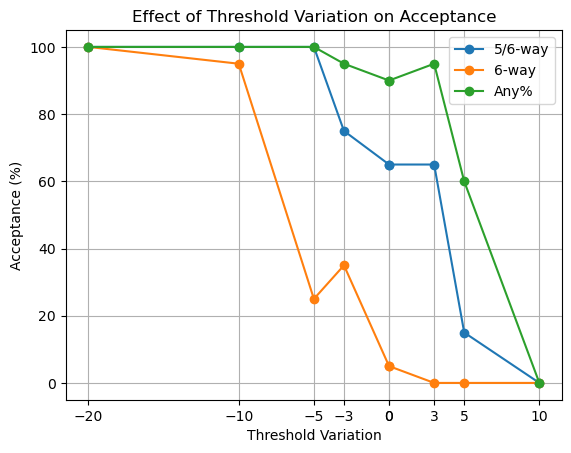

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) Subset the rows for base ± threshold
#    Adjust these row labels as they appear in your DataFrame index.
rows_of_interest = [
    "Base (-20)",
    "Base (-10)",
    "Base (-5)",
    "Base (-3)",
    "Base",        # the "baseline" 
    "Base (+3)",
    "Base (+5)",
    "Base (+10)"
]

df_subset = df.loc[rows_of_interest].copy()

# 2) Create a numeric 'Threshold' column for the x-axis
#    Match each row label to its numeric offset:
mapping = {
    "Base (-20)": -20,
    "Base (-10)": -10,
    "Base (-5)":  -5,
    "Base (-3)":  -3,
    "Base":        0,
    "Base (+3)":   3,
    "Base (+5)":   5,
    "Base (+10)": 10
}
df_subset["Threshold"] = df_subset.index.map(mapping)

# 3) Plot the columns "5/6-way", "6-way", and "Any%" vs. "Threshold"
ax = df_subset.plot(
    x="Threshold",
    y=["5/6-way", "6-way", "Any%"],
    kind="line",
    marker="o",        # optional: put markers
    xlabel="Threshold Variation",
    ylabel="Acceptance (%)",
    title="Effect of Threshold Variation on Acceptance"
)

plt.xticks(df_subset["Threshold"])  # ensure x-ticks match our threshold values exactly
plt.grid(True)
plt.show()
